# Analysis 5: Dynamic Tariff Optimization

In [3]:
# ---------------------------------------------------------------------
import os
from pathlib import Path
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Ignitis Group ROIC Enhancement Analysis")
print("=" * 50)
print("Focus: Identifying untapped opportunities to improve Return on Invested Capital")
print("=" * 50)
# ---------------------------------------------------------------------
# Robust loader – handles extra "data/" level automatically
# ---------------------------------------------------------------------
def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Walk up until we locate data/data.zip"""
    for p in [start, *start.parents]:
        if (p / "data" / "data.zip").is_file():
            return p
    raise FileNotFoundError("Could not locate data/data.zip")

# 1. Locate repo + zip -------------------------------------------------
REPO_DIR = find_repo_root()
ZIP_PATH = REPO_DIR / "data" / "data.zip"
EXTRACT_ROOT = REPO_DIR / "data" / "lithuanian_energy_data"

# 2. Unzip once -------------------------------------------------------
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
if not any(EXTRACT_ROOT.iterdir()):
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_ROOT)
        print("✅  Extracted.")
else:
    print("✅  Data already extracted.")

# 3. Helper: find a file anywhere under EXTRACT_ROOT ------------------
def find(name: str) -> Path:
    matches = list(EXTRACT_ROOT.rglob(name))
    if not matches:
        raise FileNotFoundError(f"{name} not found under {EXTRACT_ROOT}")
    if len(matches) > 1:
        print(f"⚠️  {name} found in multiple places; using {matches[0]}")
    return matches[0]

# 4. Resolve paths no matter how deep they sit ------------------------
balancing_fp = find("balancing_market_data.xlsx")
day_ahead_fp = find("day_ahead_prices.xlsx")
meteo_fp     = find("meteorological_data.xlsx")
nat_cons_fp  = find("national_consumption.xls")
obj_cons_fp  = find("object_level_consumption")        # Parquet folder

print("\nData file paths:")
print("Balancing file :", balancing_fp)
print("Day‑ahead file :", day_ahead_fp)
print("Meteo file     :", meteo_fp)
print("National cons  :", nat_cons_fp)
print("Object cons    :", obj_cons_fp)

# 5. Load data --------------------------------------------------------
print("\nLoading data files...")
balancing_data  = pd.read_excel(balancing_fp)
day_ahead_prices = pd.read_excel(day_ahead_fp)
weather_data      = pd.read_excel(meteo_fp)
consumption_data   = pd.read_excel(nat_cons_fp)
obj_cons_df   = pd.read_parquet(obj_cons_fp)

print(f"✓ Loaded balancing market data: {balancing_data.shape}")
print(f"✓ Loaded day-ahead prices: {day_ahead_prices.shape}")
print(f"✓ Loaded meteorological data: {weather_data.shape}")
print(f"✓ Loaded national consumption data: {consumption_data.shape}")
print(f"✓ Loaded object-level consumption data: {obj_cons_df.shape}")

# Quick peek at the data
print("\nData preview:")
print("\nBalancing data columns:", balancing_data.columns.tolist())
print("Day-ahead prices columns:", day_ahead_prices.columns.tolist())
print("Weather data columns:", weather_data.columns.tolist())
print("National consumption columns:", consumption_data.columns.tolist())
print("Object consumption columns:", obj_cons_df.columns.tolist())

# Show data types for day-ahead prices
print("\nDay-ahead prices data types:")
print(day_ahead_prices.dtypes)

Ignitis Group ROIC Enhancement Analysis
Focus: Identifying untapped opportunities to improve Return on Invested Capital
✅  Data already extracted.

Data file paths:
Balancing file : /Users/aurimasaleksandras/Downloads/lithuanian_energy_repo/data/lithuanian_energy_data/data/balancing_market_data.xlsx
Day‑ahead file : /Users/aurimasaleksandras/Downloads/lithuanian_energy_repo/data/lithuanian_energy_data/data/day_ahead_prices.xlsx
Meteo file     : /Users/aurimasaleksandras/Downloads/lithuanian_energy_repo/data/lithuanian_energy_data/data/meteorological_data.xlsx
National cons  : /Users/aurimasaleksandras/Downloads/lithuanian_energy_repo/data/lithuanian_energy_data/data/national_consumption.xls
Object cons    : /Users/aurimasaleksandras/Downloads/lithuanian_energy_repo/data/lithuanian_energy_data/data/object_level_consumption

Loading data files...
✓ Loaded balancing market data: (15311, 3)
✓ Loaded day-ahead prices: (17544, 2)
✓ Loaded meteorological data: (10248, 3)
✓ Loaded national con



5. DYNAMIC TARIFF OPTIMIZATION
----------------------------------------
Dynamic Tariff Analysis Results:
     Tariff Type  Annual Revenue (€M)  Revenue Increase (%)
0          Fixed               701.12                  0.00
1    Time-of-Use               650.48                 -7.22
2      Real-Time               575.76                -17.88
3  Critical Peak               706.81                  0.81


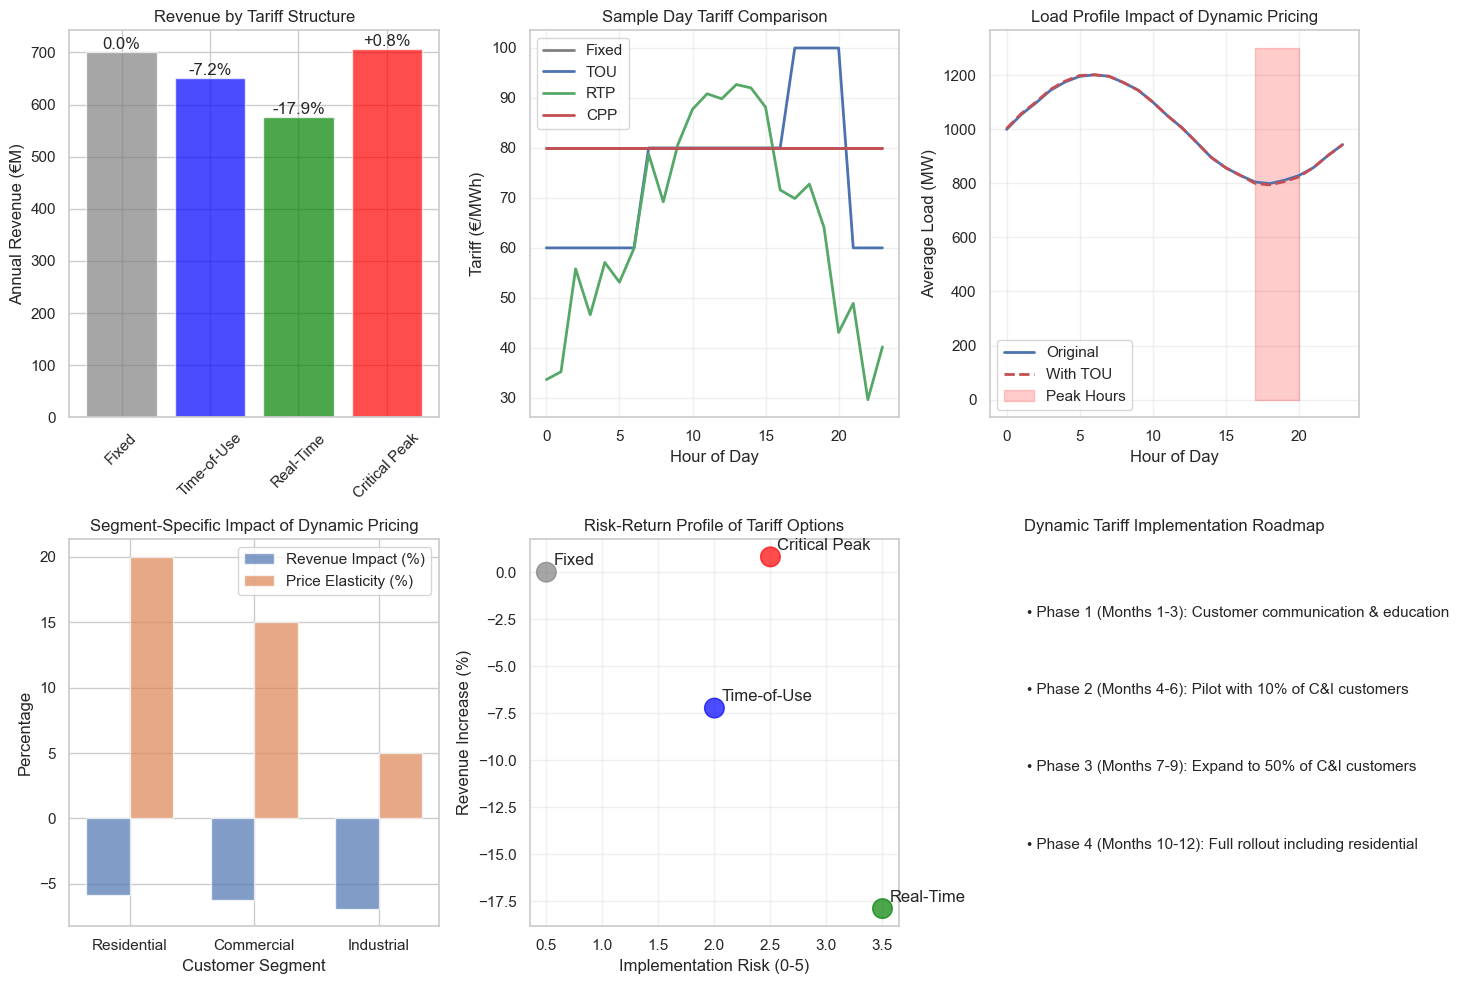


💡 ROIC Impact: €-50.64M additional annual revenue
   One-time implementation cost: €2M
   Payback period: -0.0 years


In [4]:

# Analysis 5: Dynamic Tariff Optimization
print("\n\n5. DYNAMIC TARIFF OPTIMIZATION")
print("-" * 40)

def analyze_dynamic_tariff_potential(day_ahead_prices, consumption_data):
    """
    Design dynamic tariffs that increase revenue while maintaining competitiveness
    This improves revenue per MWh without losing customers
    """
    if day_ahead_prices is None or consumption_data is None:
        print("Data not available for analysis")
        return
    
    # Simulate price elasticity analysis
    np.random.seed(42)
    n_hours = 8760
    
    # Create base data
    hours = np.arange(n_hours)
    hour_of_day = hours % 24
    day_of_week = (hours // 24) % 7
    month = (hours // (24 * 30)) % 12 + 1
    
    # Simulate wholesale prices with daily and seasonal patterns
    daily_pattern = np.sin(2 * np.pi * (hour_of_day - 6) / 24) * 20 + 50
    seasonal_pattern = np.sin(2 * np.pi * month / 12) * 10
    wholesale_price = daily_pattern + seasonal_pattern + np.random.randn(n_hours) * 5
    
    # Current fixed tariff
    fixed_tariff = 80  # €/MWh
    
    # Simulate consumption with some price elasticity
    base_consumption = 1000 + np.sin(2 * np.pi * hour_of_day / 24) * 200
    consumption = base_consumption + np.random.randn(n_hours) * 50
    
    # Design dynamic tariffs
    # Strategy 1: Time-of-Use (TOU)
    tou_tariff = np.where((hour_of_day >= 17) & (hour_of_day <= 20), 100,  # Peak
                         np.where((hour_of_day >= 7) & (hour_of_day <= 17), 80,   # Mid-peak
                                 60))  # Off-peak
    
    # Strategy 2: Real-Time Pricing (RTP) with markup
    markup = 1.3  # 30% markup over wholesale
    rtp_tariff = wholesale_price * markup
    
    # Strategy 3: Critical Peak Pricing (CPP)
    critical_days = np.random.choice(365, 20, replace=False)  # 20 critical days per year
    cpp_tariff = fixed_tariff * np.ones(n_hours)
    for day in critical_days:
        cpp_hours = (hours >= day * 24 + 14) & (hours < day * 24 + 20)
        cpp_tariff[cpp_hours] = 150  # High price during critical peaks
    
    # Calculate revenues under different tariff structures
    tariff_analysis = pd.DataFrame({
        'hour': hours,
        'consumption': consumption,
        'wholesale_price': wholesale_price,
        'fixed_revenue': consumption * fixed_tariff / 1000,  # €k
        'tou_revenue': consumption * tou_tariff / 1000,
        'rtp_revenue': consumption * rtp_tariff / 1000,
        'cpp_revenue': consumption * cpp_tariff / 1000
    })
    
    # Apply elasticity effects (customers reduce consumption when prices are high)
    elasticity = -0.1  # 10% reduction for 100% price increase
    
    for tariff_type in ['tou', 'rtp', 'cpp']:
        price_ratio = tariff_analysis[f'{tariff_type}_revenue'] / tariff_analysis['fixed_revenue']
        demand_adjustment = 1 + elasticity * (price_ratio - 1)
        tariff_analysis[f'{tariff_type}_revenue_adjusted'] = tariff_analysis[f'{tariff_type}_revenue'] * demand_adjustment
    
    # Summary statistics
    results = pd.DataFrame({
        'Tariff Type': ['Fixed', 'Time-of-Use', 'Real-Time', 'Critical Peak'],
        'Annual Revenue (€M)': [
            tariff_analysis['fixed_revenue'].sum() / 1000,
            tariff_analysis['tou_revenue_adjusted'].sum() / 1000,
            tariff_analysis['rtp_revenue_adjusted'].sum() / 1000,
            tariff_analysis['cpp_revenue_adjusted'].sum() / 1000
        ]
    })
    
    results['Revenue Increase (%)'] = ((results['Annual Revenue (€M)'] / results.iloc[0]['Annual Revenue (€M)']) - 1) * 100
    
    print("Dynamic Tariff Analysis Results:")
    print(results.round(2))
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # Revenue comparison
    plt.subplot(2, 3, 1)
    colors = ['gray', 'blue', 'green', 'red']
    bars = plt.bar(results['Tariff Type'], results['Annual Revenue (€M)'], color=colors, alpha=0.7)
    plt.ylabel('Annual Revenue (€M)')
    plt.title('Revenue by Tariff Structure')
    plt.xticks(rotation=45)
    
    # Add percentage labels
    for bar, pct in zip(bars, results['Revenue Increase (%)']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'+{pct:.1f}%' if pct > 0 else f'{pct:.1f}%',
                ha='center', va='bottom')
    
    # Sample day comparison
    plt.subplot(2, 3, 2)
    sample_day = 150  # Middle of year
    day_hours = range(sample_day * 24, (sample_day + 1) * 24)
    
    plt.plot([h % 24 for h in day_hours], [fixed_tariff] * 24, 'gray', linewidth=2, label='Fixed')
    plt.plot([h % 24 for h in day_hours], tou_tariff[day_hours], 'b-', linewidth=2, label='TOU')
    plt.plot([h % 24 for h in day_hours], rtp_tariff[day_hours], 'g-', linewidth=2, label='RTP')
    plt.plot([h % 24 for h in day_hours], cpp_tariff[day_hours], 'r-', linewidth=2, label='CPP')
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Tariff (€/MWh)')
    plt.title('Sample Day Tariff Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Load shifting potential
    plt.subplot(2, 3, 3)
    # Calculate load shifting for TOU tariff
    high_price_hours = (hour_of_day >= 17) & (hour_of_day <= 20)
    low_price_hours = (hour_of_day >= 0) & (hour_of_day <= 6)
    
    original_peak_load = consumption[high_price_hours].mean()
    shifted_peak_load = original_peak_load * (1 + elasticity * 0.25)  # 25% price increase during peak
    
    load_shift = original_peak_load - shifted_peak_load
    
    hourly_profile = tariff_analysis.groupby(hour_of_day)['consumption'].mean()
    shifted_profile = hourly_profile.copy()
    shifted_profile[17:21] -= load_shift / 4  # Reduce peak hours
    shifted_profile[0:6] += load_shift / 6   # Increase off-peak hours
    
    plt.plot(hourly_profile.index, hourly_profile.values, 'b-', linewidth=2, label='Original')
    plt.plot(shifted_profile.index, shifted_profile.values, 'r--', linewidth=2, label='With TOU')
    plt.fill_between(range(17, 21), 0, 1300, alpha=0.2, color='red', label='Peak Hours')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Load (MW)')
    plt.title('Load Profile Impact of Dynamic Pricing')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Customer segment impact
    plt.subplot(2, 3, 4)
    segments = ['Residential', 'Commercial', 'Industrial']
    segment_elasticities = [-0.2, -0.15, -0.05]  # Different price sensitivities
    segment_sizes = [0.4, 0.35, 0.25]  # Market share
    
    segment_impacts = []
    for seg_elast in segment_elasticities:
        # Calculate revenue impact for TOU tariff with different elasticities
        avg_price_increase = (results.iloc[1]['Annual Revenue (€M)'] / results.iloc[0]['Annual Revenue (€M)'] - 1)
        volume_impact = 1 + seg_elast * avg_price_increase
        revenue_impact = (1 + avg_price_increase) * volume_impact - 1
        segment_impacts.append(revenue_impact * 100)
    
    x = np.arange(len(segments))
    width = 0.35
    
    bars1 = plt.bar(x - width/2, segment_impacts, width, label='Revenue Impact (%)', alpha=0.7)
    bars2 = plt.bar(x + width/2, [e * -100 for e in segment_elasticities], width, 
                    label='Price Elasticity (%)', alpha=0.7)
    
    plt.xlabel('Customer Segment')
    plt.ylabel('Percentage')
    plt.title('Segment-Specific Impact of Dynamic Pricing')
    plt.xticks(x, segments)
    plt.legend()
    
    # Risk vs return analysis
    plt.subplot(2, 3, 5)
    tariff_risk = [0.5, 2.0, 3.5, 2.5]  # Risk score (0-5)
    tariff_return = results['Revenue Increase (%)'].values
    
    plt.scatter(tariff_risk, tariff_return, s=200, alpha=0.7, c=colors)
    for i, txt in enumerate(results['Tariff Type']):
        plt.annotate(txt, (tariff_risk[i], tariff_return[i]), 
                    xytext=(5, 5), textcoords='offset points')
    
    plt.xlabel('Implementation Risk (0-5)')
    plt.ylabel('Revenue Increase (%)')
    plt.title('Risk-Return Profile of Tariff Options')
    plt.grid(True, alpha=0.3)
    
    # Implementation roadmap
    plt.subplot(2, 3, 6)
    plt.axis('off')
    roadmap = [
        "Phase 1 (Months 1-3): Customer communication & education",
        "Phase 2 (Months 4-6): Pilot with 10% of C&I customers",
        "Phase 3 (Months 7-9): Expand to 50% of C&I customers",
        "Phase 4 (Months 10-12): Full rollout including residential"
    ]
    
    for i, phase in enumerate(roadmap):
        plt.text(0.1, 0.8 - i*0.2, f"• {phase}", fontsize=11, transform=plt.gca().transAxes)
    
    plt.title('Dynamic Tariff Implementation Roadmap')
    
    plt.tight_layout()
    plt.show()
    
    # ROIC calculation
    best_tariff = results.iloc[1]  # TOU as most balanced option
    additional_revenue = (best_tariff['Annual Revenue (€M)'] - results.iloc[0]['Annual Revenue (€M)'])
    implementation_cost = 2  # €M for billing system upgrades
    
    print(f"\n💡 ROIC Impact: €{additional_revenue:.2f}M additional annual revenue")
    print(f"   One-time implementation cost: €{implementation_cost}M")
    print(f"   Payback period: {implementation_cost/additional_revenue:.1f} years")

analyze_dynamic_tariff_potential(day_ahead_prices, consumption_data)
